<a href="https://colab.research.google.com/github/viunadyapage/pengolahan-citra-digital/blob/main/2.%20Representasi%20Citra%20Digital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktek 2

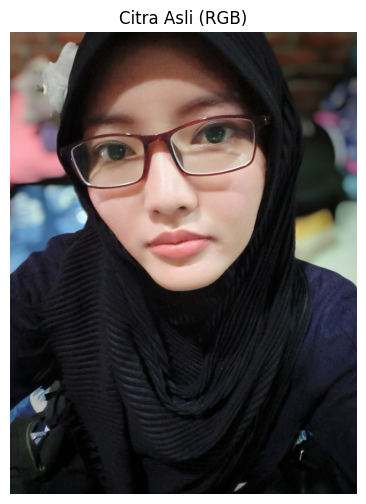

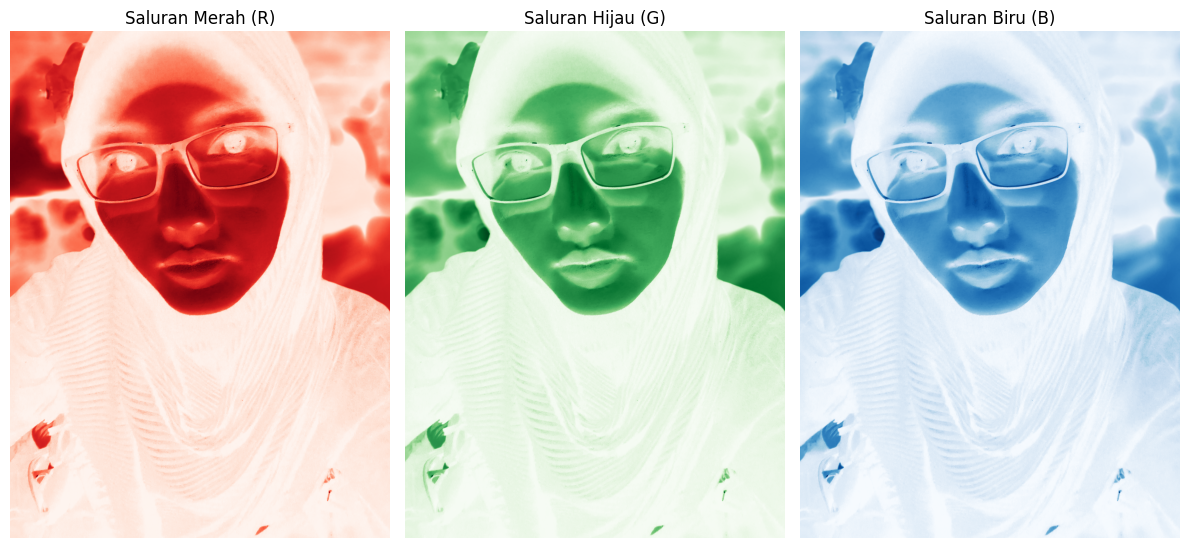

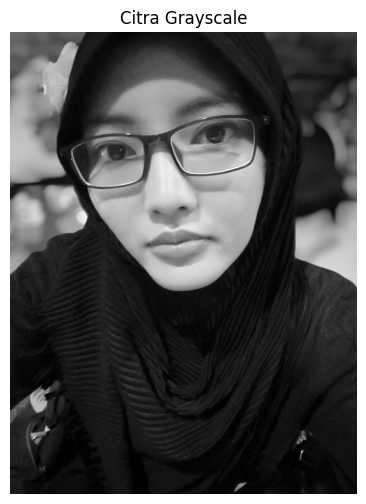

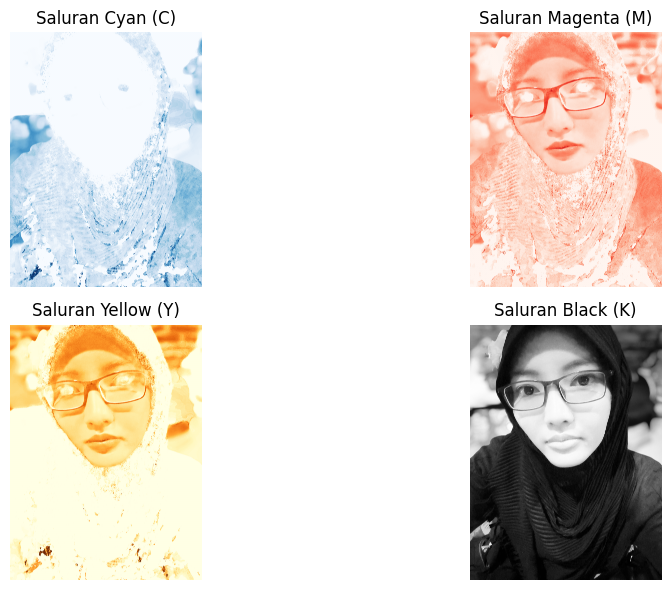

Proses selesai! Anda telah memvisualisasikan model warna RGB, Grayscale, dan CMYK.


In [1]:
# Import library yang diperlukan
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color

# Langkah 1: Memuat citra dari URL atau file lokal
# Untuk praktikum ini, saya akan menggunakan URL drive gambar muka saya
url = 'https://drive.google.com/uc?export=download&id=1yQPIxMa06jJq5K_GBrn_n0gJzIdTyA7b'

# Mengunduh gambar dari URL
import urllib.request
urllib.request.urlretrieve(url, "nadya_tirta.png.png")

# Membaca citra menggunakan OpenCV
image = cv2.imread("nadya_tirta.png.png")

# Konversi citra dari BGR (default OpenCV) ke RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Langkah 2: Menampilkan citra asli
plt.figure(figsize=(8, 6))
plt.title("Citra Asli (RGB)")
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

# Langkah 3: Memisahkan saluran warna RGB
r, g, b = cv2.split(image_rgb)

# Menampilkan setiap saluran warna
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title("Saluran Merah (R)")
plt.imshow(r, cmap='Reds')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saluran Hijau (G)")
plt.imshow(g, cmap='Greens')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Saluran Biru (B)")
plt.imshow(b, cmap='Blues')
plt.axis('off')

plt.tight_layout()
plt.show()

# Langkah 4: Konversi citra ke Grayscale
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Menampilkan citra grayscale
plt.figure(figsize=(8, 6))
plt.title("Citra Grayscale")
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

# Langkah 5: Konversi citra ke CMYK
def rgb_to_cmyk(rgb_image):
    # Normalisasi nilai RGB ke rentang [0, 1]
    rgb_normalized = rgb_image.astype(np.float32) / 255.0

    # Hitung nilai K (Black)
    k = 1 - np.max(rgb_normalized, axis=2)

    # Hitung nilai C, M, Y
    c = (1 - rgb_normalized[:, :, 0] - k) / (1 - k + 1e-10)
    m = (1 - rgb_normalized[:, :, 1] - k) / (1 - k + 1e-10)
    y = (1 - rgb_normalized[:, :, 2] - k) / (1 - k + 1e-10)

    return c, m, y, k

c, m, y, k = rgb_to_cmyk(image_rgb)

# Menampilkan saluran CMYK
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.title("Saluran Cyan (C)")
plt.imshow(c, cmap='Blues')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Saluran Magenta (M)")
plt.imshow(m, cmap='Reds')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Saluran Yellow (Y)")
plt.imshow(y, cmap='YlOrBr')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Saluran Black (K)")
plt.imshow(k, cmap='Greys')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Proses selesai! Anda telah memvisualisasikan model warna RGB, Grayscale, dan CMYK.")